# Taller Análisis Exploratorio de Datos
# Santiago Vieira y Sara Franco 

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?



In [4]:
# Respuestas a las preguntas
# - El data frame tiene 7043 filas y 33 columnas.
# - El Tipo de dato de cada columna es el siguiente:
df.info()
# - La mayoría de las variables están correctamente tipadas; sin embargo, Total Charges debería convertirse a float para un analisis más preciso.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [2]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"

file_name = "Telco_customer_churn.csv"
file_path = DATA_DIR / file_name

df = pd.read_csv(file_path)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [ ]:
print(df.columns)
df.head()
#df.describe()
# - Este analisis muestra que las variables numericas se encuentran en rangos razonables y no imposibles.
# como sugiere el dominio del problema, la unica variable constanteque se podria eliminar en este caso es count.
# - Si la variable count no varia ya que sus valores son de 0 a 1 y no aportan al analisis y pueden eliminarse.
# - variables cualitativas con alta cardinalidad como CustomerID, City y Zip Code por que identifican al usuario.
# - La vairable customerID es un identificador unico para cada cliente.

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [ ]:
df.isnull().sum()
# La única variable con valores nulos es Churn Reason, 
# con 5174 registros faltantes, y esto es consistente con el significado de la variable dentro del contexto del dataset.
df.duplicated().sum()
# se observa que no hay registros duplicados en el dataset, lo cual es positivo para el análisis.
# la unica seria a vista total charges ya que esto representa dinero y esta guardado como object y no como float.



np.int64(0)

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

In [ ]:
# El analisis de normalidad nos dice 
# Estas están más cercanas a 0:
#Churn Value  -0.870
#Churn Score  -1.006 (muy cerca del límite)
#CLTV  -0.934

#podrian ser normales pero no perfectamente normales.
# usando la Kurtosis de cada uno de las variables cuantitativas del dataset.

Matplotlib is building the font cache; this may take a moment.


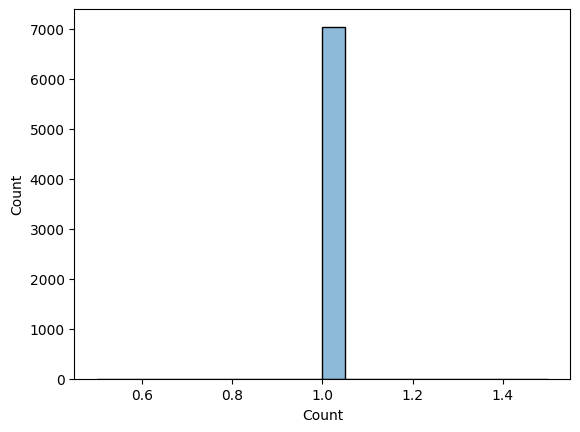

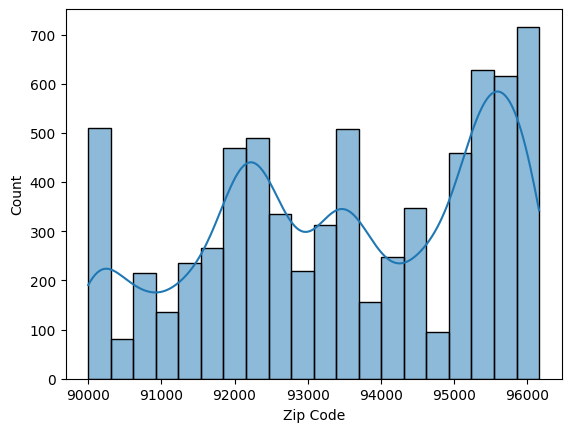

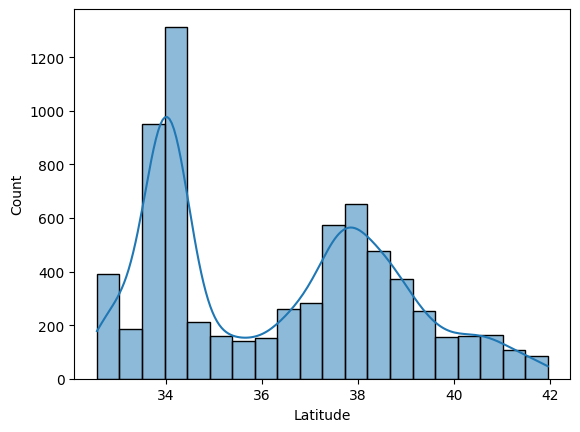

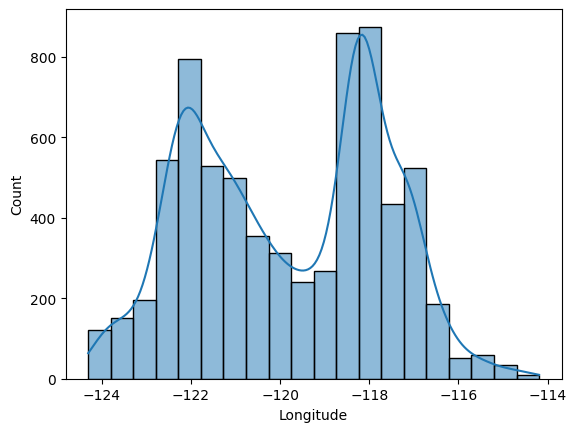

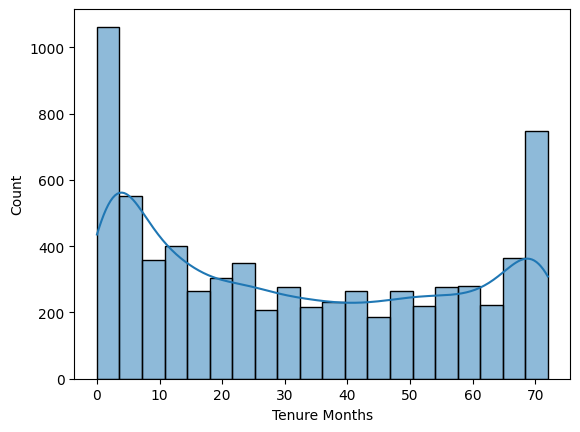

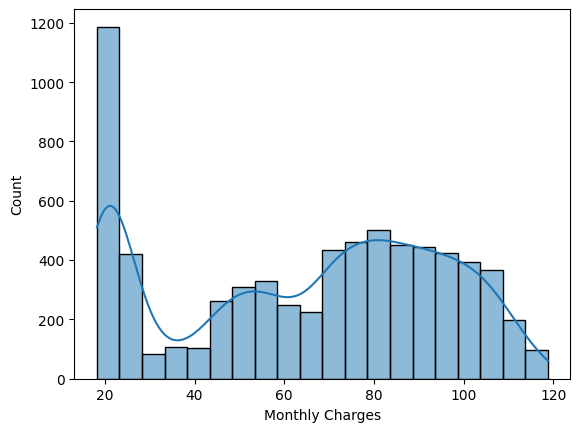

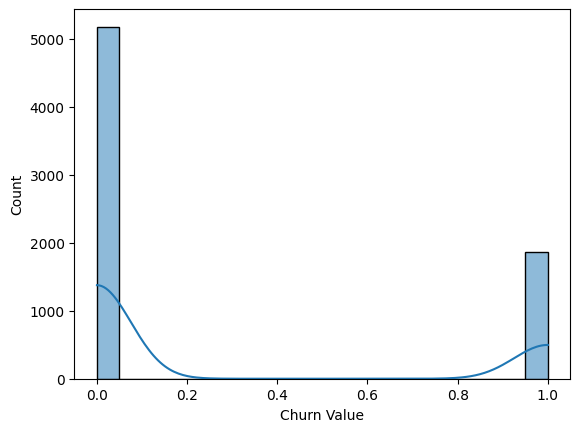

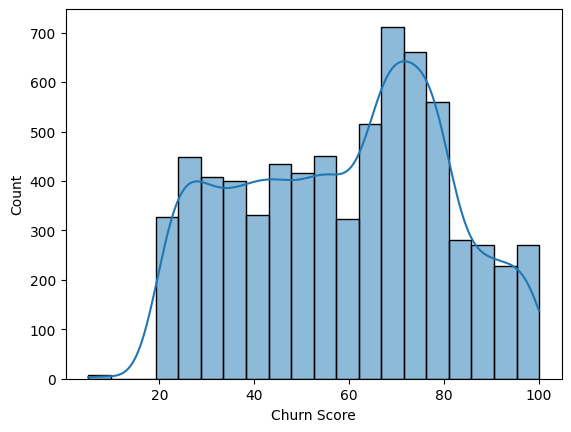

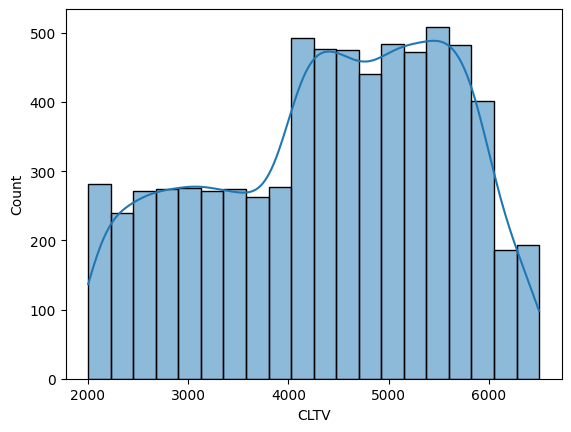

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

In [21]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")
    

Kurtosis de Count: 0.000 

Kurtosis de Zip Code: -1.154 

Kurtosis de Latitude: -1.136 

Kurtosis de Longitude: -1.136 

Kurtosis de Tenure Months: -1.387 

Kurtosis de Monthly Charges: -1.257 

Kurtosis de Churn Value: -0.870 

Kurtosis de Churn Score: -1.006 

Kurtosis de CLTV: -0.934 



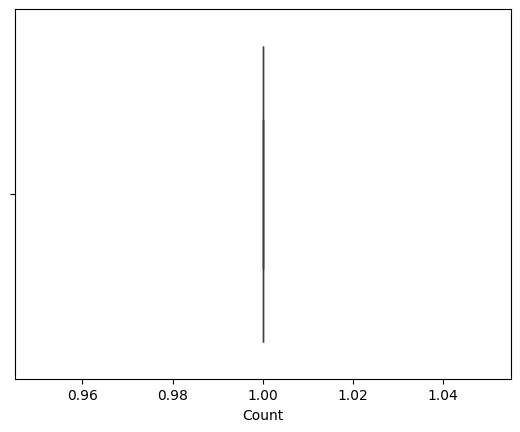

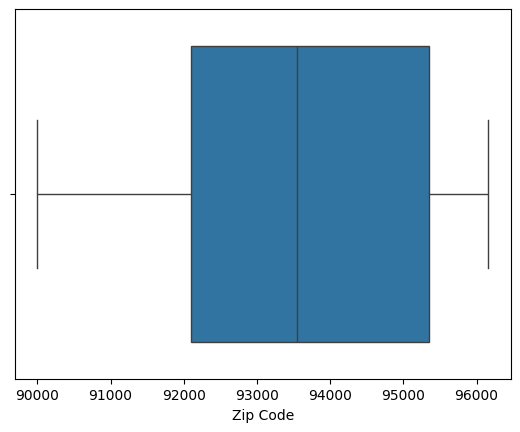

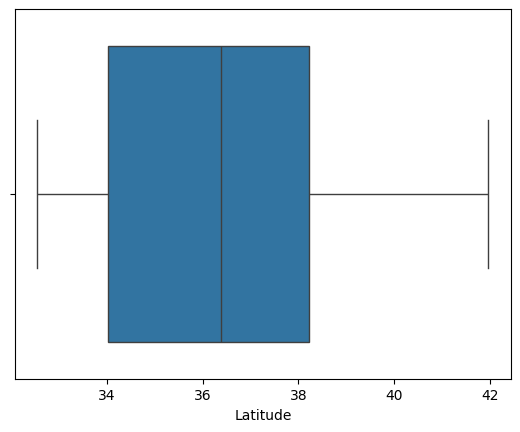

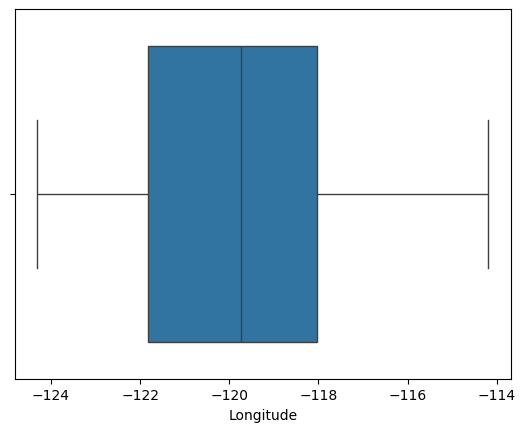

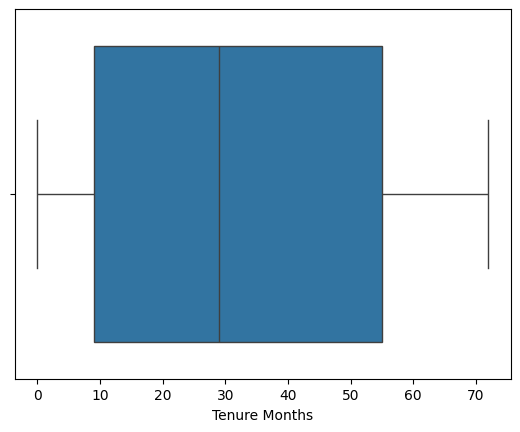

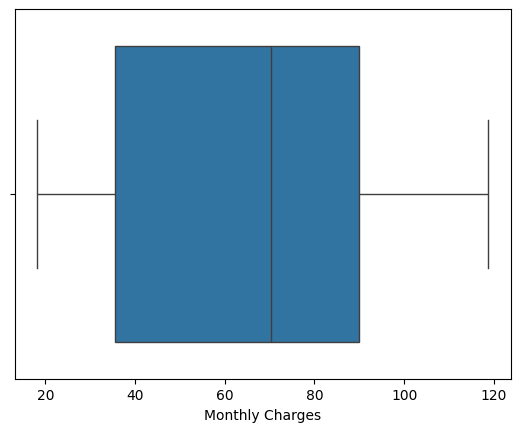

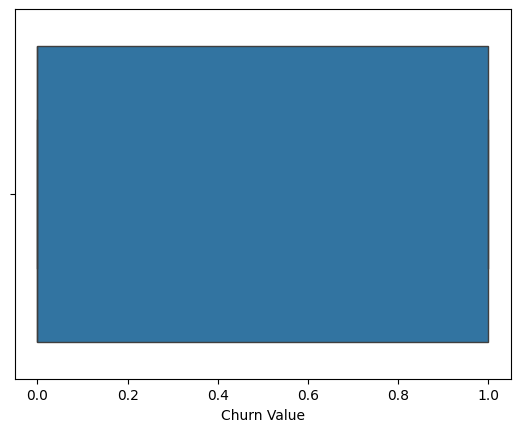

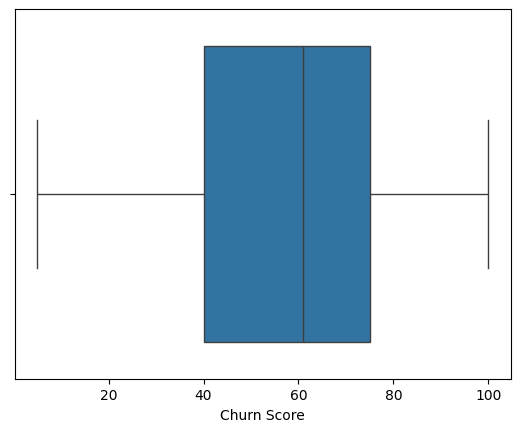

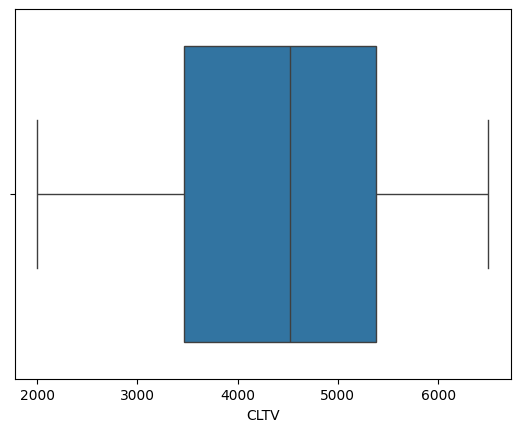

In [23]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show()

In [ ]:
# Las variables no tienen outliers significativos 
# sin embargo hay 2 variables que se mantienen en un rango constate y otra que varia entre 0 y 1
# - La variable Count es constante con un valor de 1. (constante)
# - La variable Churn Value varía entre 0 y 1 

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [3]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable CustomerID es: 
 CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64 

El conteo de la variable Country es: 
 Country
United States    7043
Name: count, dtype: int64 

El conteo de la variable State es: 
 State
California    7043
Name: count, dtype: int64 

El conteo de la variable City es: 
 City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64 

El conteo de la variable Lat Long es: 
 Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
41.505916, 

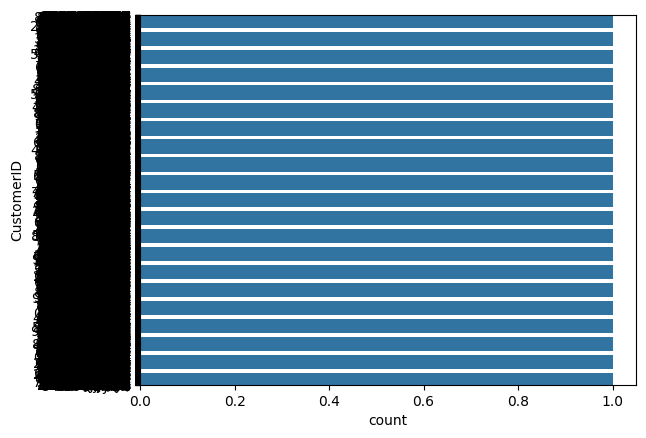

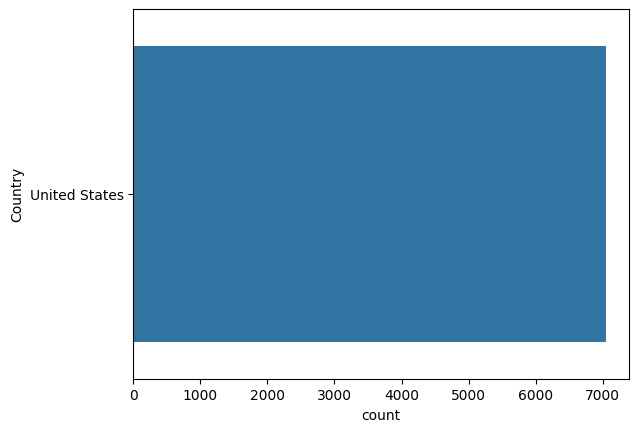

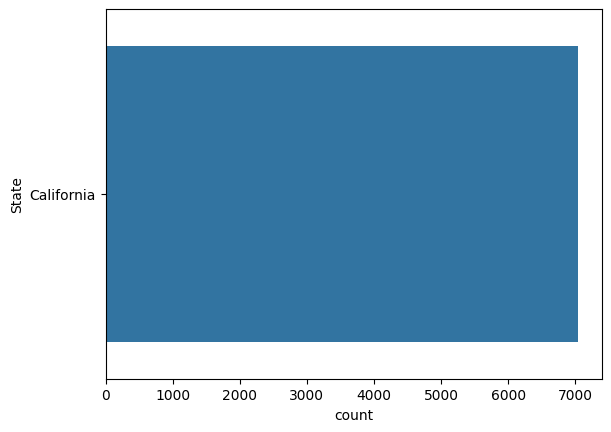

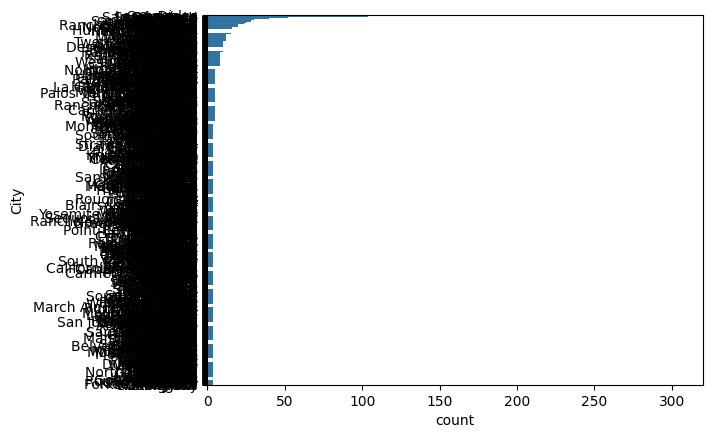

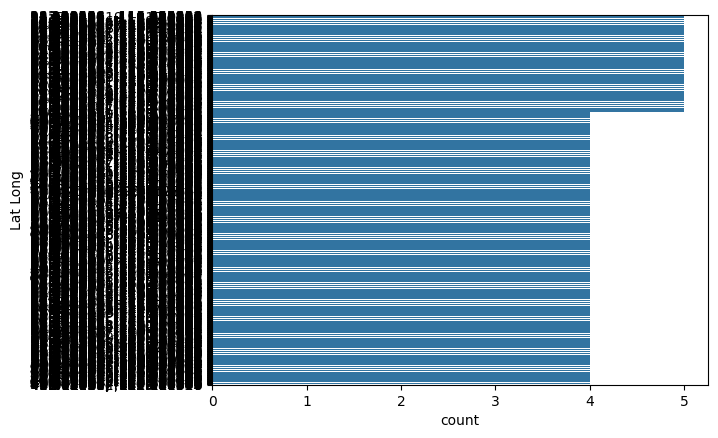

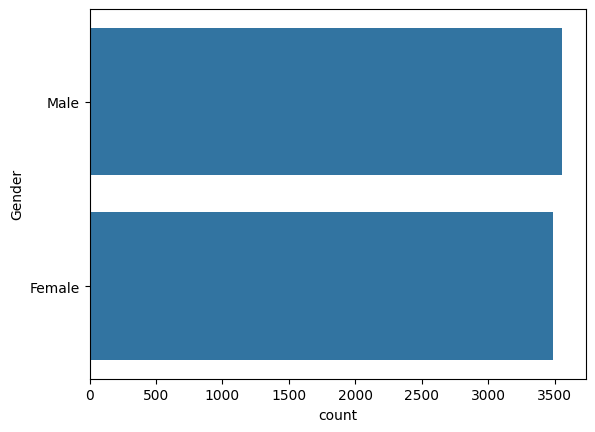

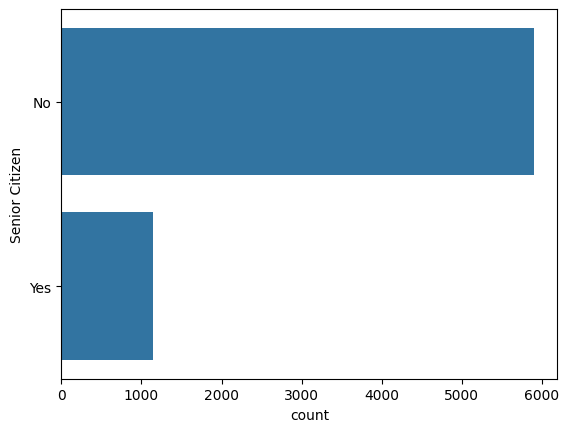

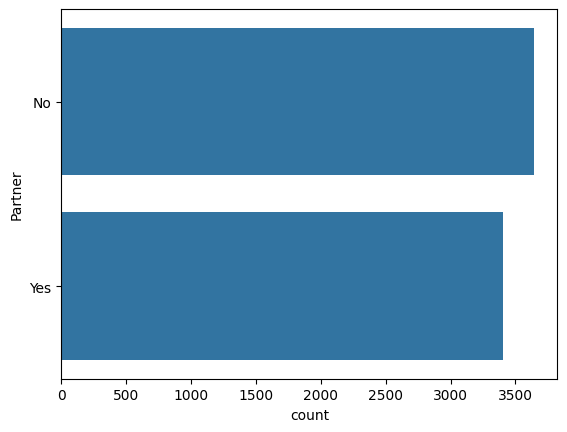

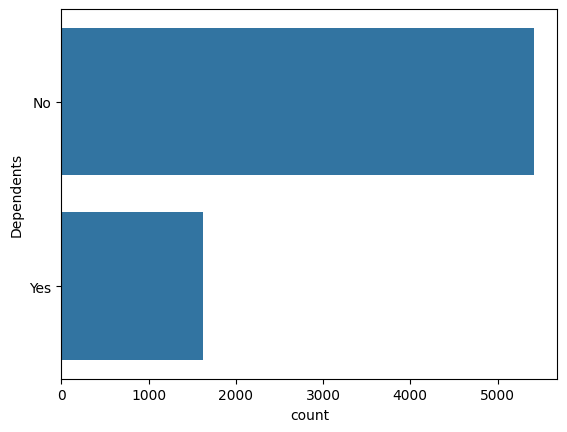

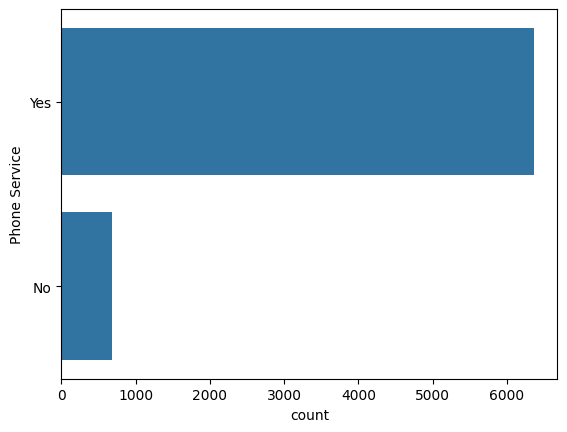

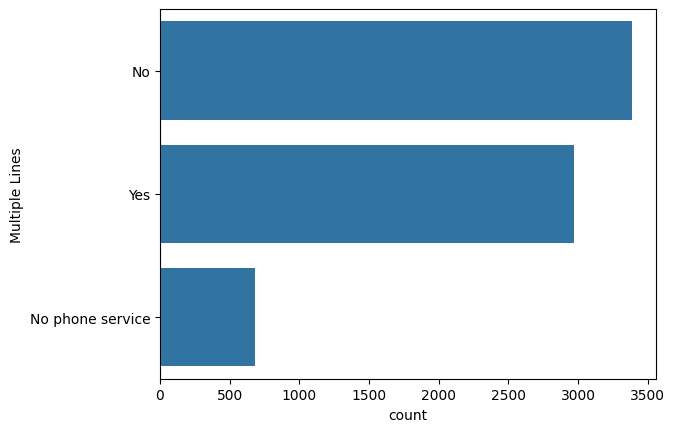

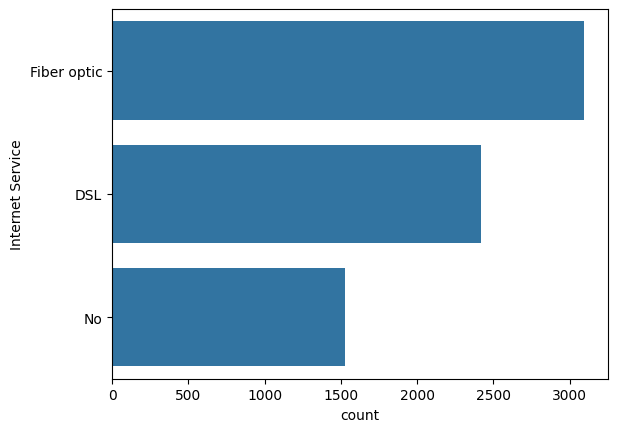

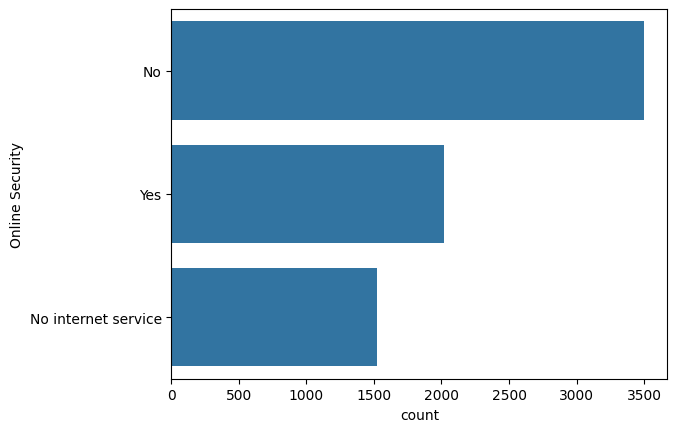

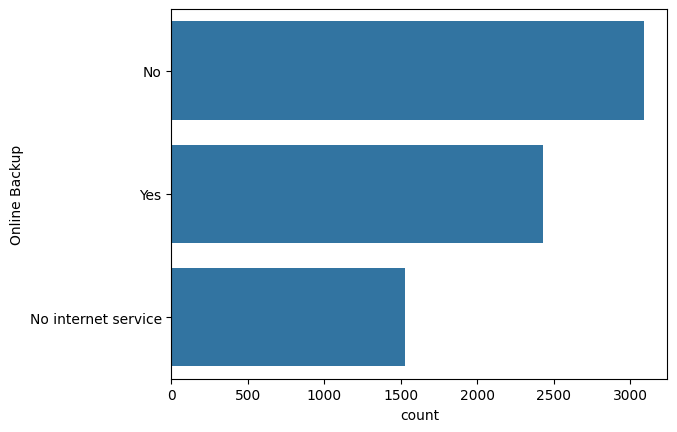

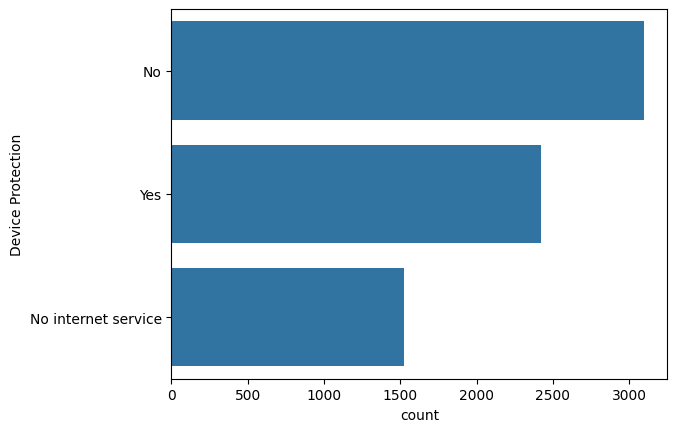

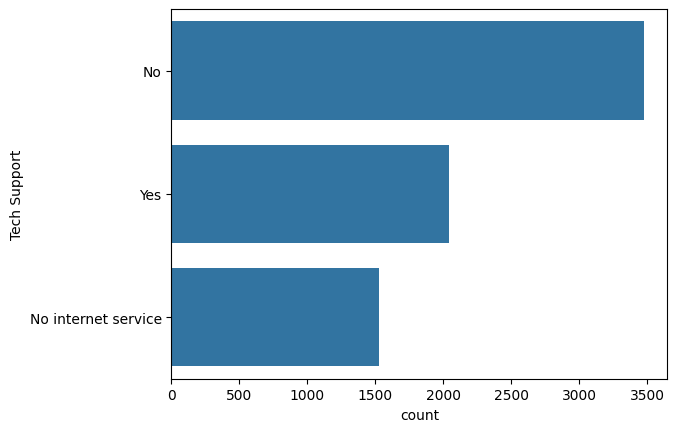

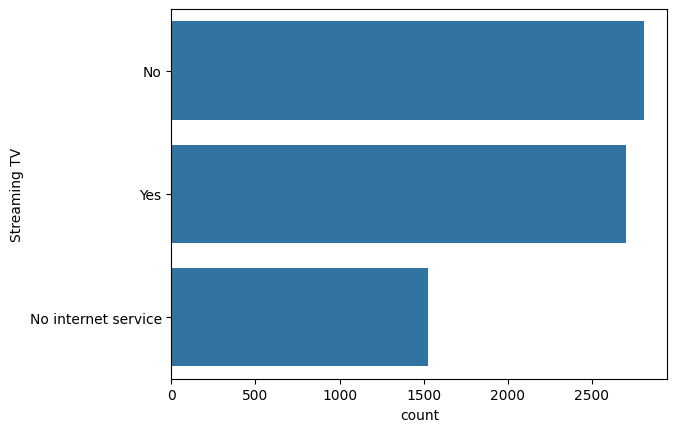

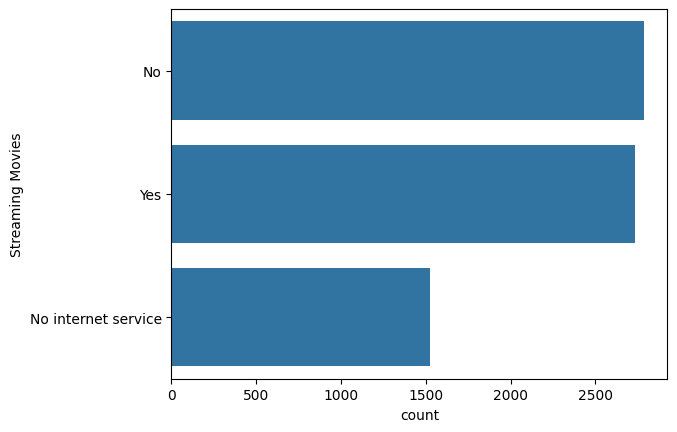

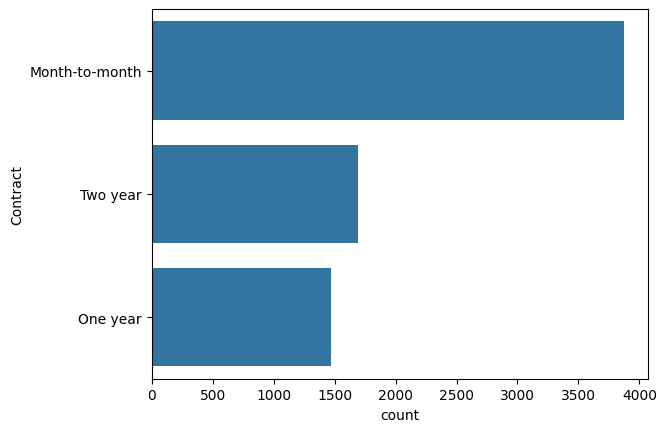

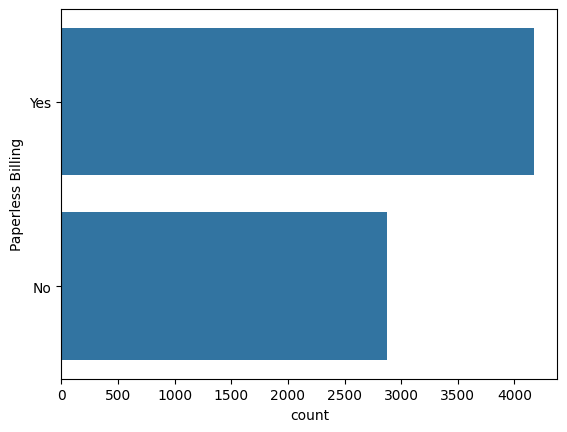

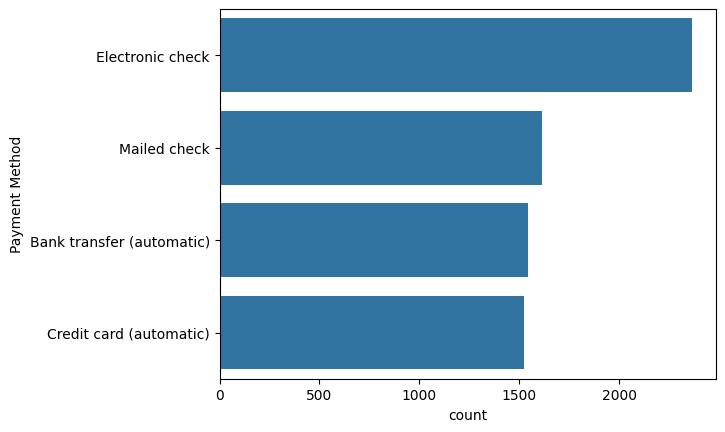

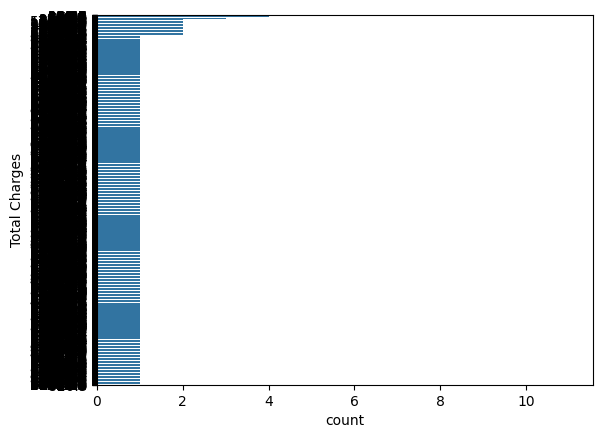

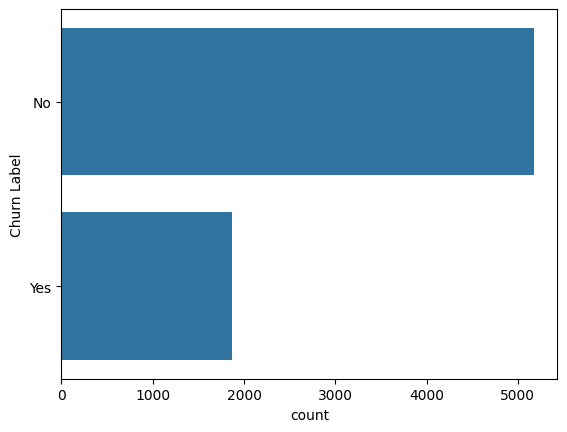

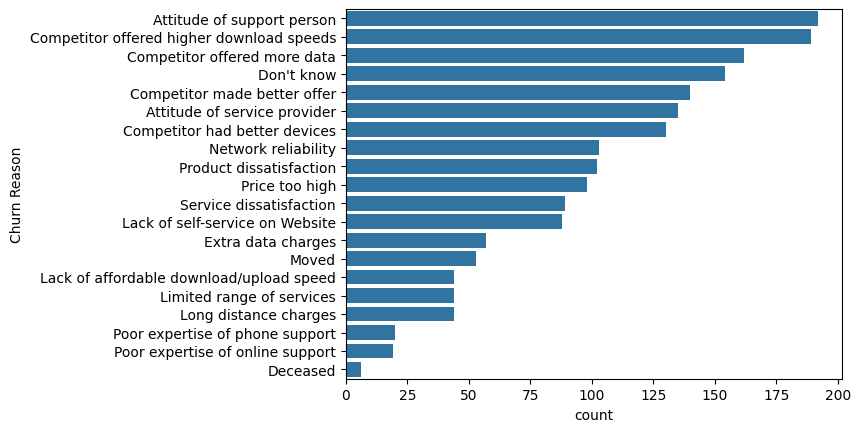

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show()

In [ ]:
# La mayoría de las variables categóricas presentan baja cardinalidad, con entre 2 y 4 categorías, 
# lo que facilita su interpretación. Por ejemplo, 
# Gender muestra una distribución casi equilibrada entre hombres y mujeres. En contraste, 
# algunas variables presentan cierto desbalance, como Senior Citizen (16.2% Yes), 
# Dependents (23.1% Yes) y Phone Service (90.3% Yes).
#  La variable Contract muestra un predominio de contratos mes a mes (55%), 
# mientras que Churn Label también se encuentra desbalanceada, con 73.5% de 
# clientes que no abandonaron el servicio. La variable con mayor cardinalidad es Churn Reason, 
# que contiene 20 categorías diferentes, aunque solo aplica a los 1869 clientes que realizaron churn.
#  En general, no se identifican categorías atípicas ni inconsistencias en la escritura de las categorías.

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


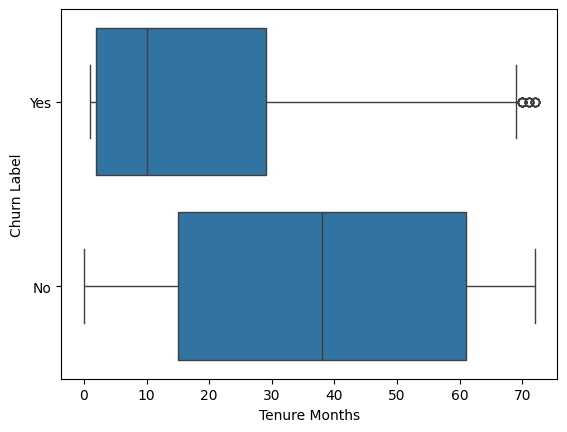

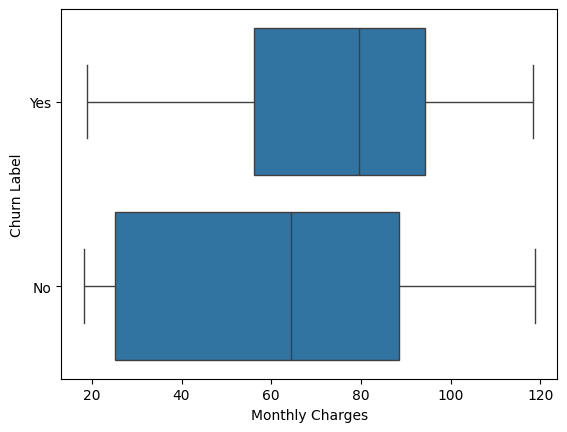

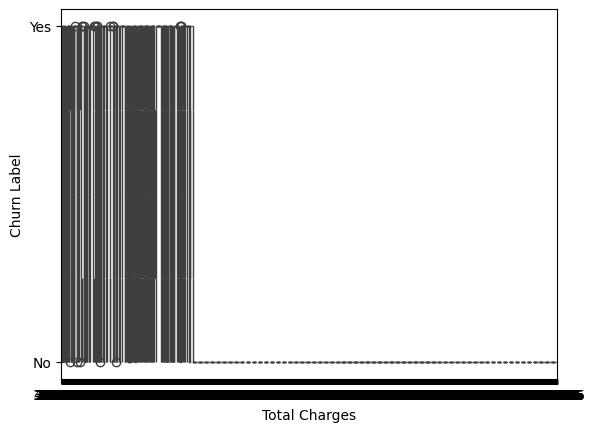

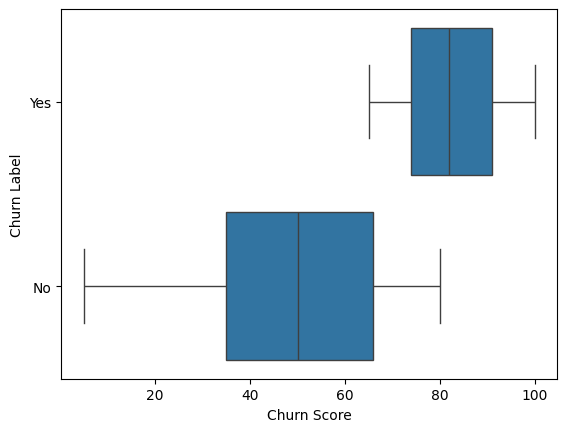

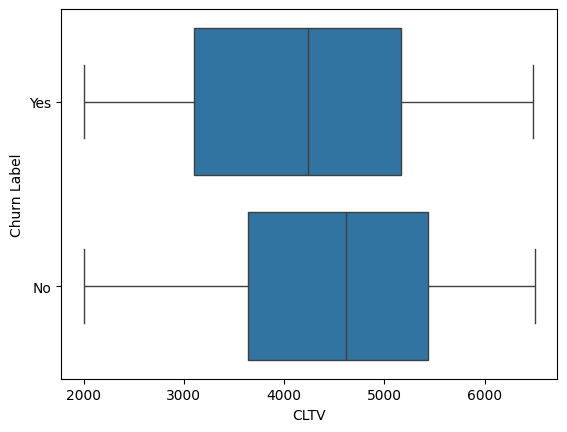

In [8]:
# Relación entre variables cuantitativas y Churn Label (variable objetivo)
for num in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']:
    plt.figure()
    sns.boxplot(data=df, y='Churn Label', x=num)
    plt.show()

In [9]:
df.groupby('Churn Label')[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']].describe()

Tenure Months                                                     \
                    count       mean        std  min   25%   50%   75%   max   
Churn Label                                                                    
No                 5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes                1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

            Monthly Charges             ... Churn Score           CLTV  \
                      count       mean  ...         75%    max   count   
Churn Label                             ...                              
No                   5174.0  61.265124  ...        66.0   80.0  5174.0   
Yes                  1869.0  74.441332  ...        91.0  100.0  1869.0   

                                                                         \
                    mean          std     min      25%     50%      75%   
Churn Label                                                               
No           4490.921337  1167.703198  2003.0  3643.75  4620.0  5434.75   
Yes          4149.414660  1189.370707  2003.0  3101.00  4238.0  5166.00   

                     
                max  
Churn Label          
No           6500.0  
Yes          6484.0  

[2 rows x 32 columns]

In [10]:
df.select_dtypes('number').corr()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,-0.127463,-0.079782,1.000000


<Axes: >

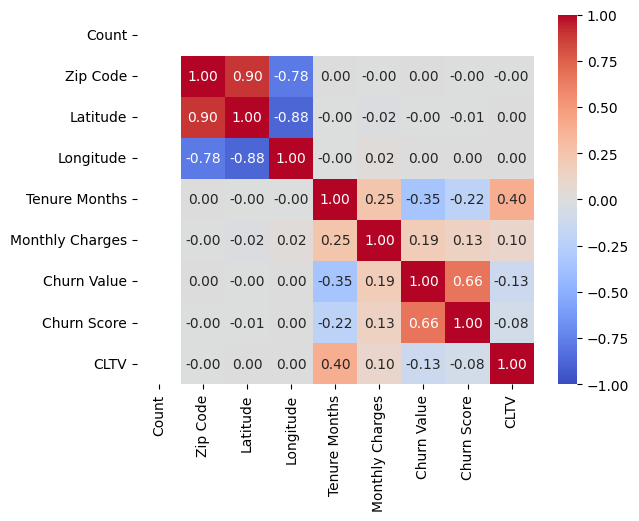

In [12]:

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
# Relación entre variables cualitativas y Churn Label (variable objetivo)
cat_vars_bi = [c for c in df.select_dtypes(include=['object']).columns
               if c not in ['Churn Label', 'Churn Reason']]

for cat in cat_vars_bi:
    print(f"\n{'='*60}")
    print(f"Variable: {cat}")
    print('='*60)

    tabla = pd.crosstab(df[cat], df['Churn Label'], normalize='index')
    print(tabla)

    plt.figure()
    sns.heatmap(tabla, annot=True, fmt='.2f', vmin=0, vmax=1)
    plt.show()

    tabla2 = pd.crosstab(df['Churn Label'], df[cat], normalize='index')
    tabla2.plot.bar(stacked=True)
    plt.show()

In [ ]:
# Variables cuantitativas:
# Las gráficas muestran que Tenure Months tiene la relación más fuerte con el churn,
# ya que los clientes que cancelan suelen tener menor tiempo de permanencia.
# Monthly Charges y Total Charges también muestran cierta relación,
# aunque más moderada. CLTV presenta una relación débil.
# Churn Score tiene una correlación alta, pero no debe usarse como predictor
# porque ya se basa en una estimación previa del churn.

# Variables cualitativas:
# Las mayores diferencias se observan en Contract, donde los contratos mes a mes
# presentan mayor churn que los contratos de largo plazo.
# También influyen Payment Method, Internet Service, Online Security
# y Tech Support, ya que la ausencia de estos servicios o ciertos métodos
# de pago se asocian con mayor churn.
# Variables como Gender, Phone Service y las variables geográficas
# muestran poca relación con el churn.

# Variables predictoras:
# Las variables que parecen mejores predictoras son Tenure Months,
# Contract, Payment Method, Internet Service, Online Security y Tech Support.
# En cambio, Gender, Phone Service, CLTV y las variables geográficas
# parecen aportar poca capacidad predictiva.